# Study 10 — Does old evidence have to disappear all at once?

Studies 07–09 showed that estimating current ability from past results creates a trade-off between **responsiveness** and **stability**.

A fixed rolling window handles stale history by forgetting observations once they become old enough. But that creates a sharp boundary:

- a frame just inside the window counts fully;
- the next-oldest frame counts not at all.

There is no obvious sporting reason why evidence should lose all of its value at one exact age.

This study keeps the same deliberately simple model as before:

- frames are independent;
- there is no momentum;
- there is no parameter uncertainty;
- a player has a 58% frame-win probability for 1,000 frames;
- ability then genuinely changes to 64%.

We change **one thing only**.

We compare:

1. the existing 250-frame rolling estimate;
2. one exponentially weighted estimate, where recent frames count more and older frames gradually count less.

The question is:

> **What changes when old evidence fades gradually rather than disappearing at a fixed cutoff?**

This is a descriptive comparison. We are not yet trying to optimise the decay rate or decide which estimator is best.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fixed seed so the simulated career is reproducible.
rng = np.random.default_rng(42)

## 1. Keep the underlying sporting model unchanged

To isolate the effect of **how old evidence is weighted**, we keep the player's underlying ability path exactly the same as in Studies 07–09.

The player has:

- a 58% probability of winning each frame for the first 1,000 frames;
- a 64% probability thereafter.

The change is genuine and abrupt.

Nothing about the frame-generating process changes in this study. The only comparison will be between two ways of estimating current ability from the observed results.

In [2]:
n_pre_change = 1_000
n_post_change = 1_000

p_before = 0.58
p_after = 0.64

true_p = np.concatenate([
    np.full(n_pre_change, p_before),
    np.full(n_post_change, p_after),
])

# Simulate one career from the unchanged 58% -> 64% ability path.
frame_wins = rng.binomial(1, true_p)

len(frame_wins), frame_wins.mean()

(2000, np.float64(0.6055))

In [3]:
# Store the simulated career in a DataFrame so each frame can be
# inspected alongside the player's true ability and observed result.
career = pd.DataFrame({
    "frame": np.arange(1, len(frame_wins) + 1),
    "true_p": true_p,
    "win": frame_wins,
})

# Check the first few rows before adding any estimators.
career.head()

,frame,true_p,win
0,1,0.58,0
1,2,0.58,1
2,3,0.58,0
3,4,0.58,0
4,5,0.58,1


## 2. Baseline: the 250-frame rolling estimate

Our baseline is the same 250-frame rolling estimate used previously.

At each point in the career, it estimates current ability from the most recent 250 observed frame results.

Every frame inside that window receives the **same weight**:

- the most recent frame counts fully;
- a frame from 100 frames ago counts fully;
- a frame from 249 frames ago counts fully;
- once a frame falls outside the window, it counts zero.

This gives the estimator a finite memory, but it also creates the hard cutoff that this study is interested in.

In [4]:
window_size = 250

# Estimate current ability from the most recent 250 observed frames.
# min_periods=window_size avoids treating short early-career histories
# as though they were directly comparable with a full 250-frame window.
career["rolling_250"] = (
    career["win"]
    .rolling(window=window_size, min_periods=window_size)
    .mean()
)

# Inspect the first point where a complete 250-frame estimate is available.
career.loc[245:252, ["frame", "win", "rolling_250"]]

,frame,win,rolling_250
245,246,0,NaN
246,247,0,NaN
247,248,1,NaN
248,249,1,NaN
249,250,1,0.580
250,251,0,0.580
251,252,0,0.576
252,253,1,0.580


## 3. Let old evidence fade gradually

A rolling window treats age as a hard boundary. An exponentially weighted estimate takes a different approach.

Every past frame can still contribute, but its weight becomes smaller as it gets older. Recent results therefore matter more, while older evidence fades gradually rather than disappearing at one exact point.

To keep this comparison as controlled as possible, we will use an exponentially weighted estimate with a **span of 250 frames**.

This is not an attempt to optimise the decay rate. The choice is useful because, under a stable independent frame-win probability, an exponential estimator with `span=250` has the same long-run **effective sample size** as an ordinary average of 250 equally weighted observations.

Effective sample size is a way of expressing how much independent information a weighted estimator contains. Two estimators can use very different weighting rules while still having broadly comparable statistical variability.

That gives us a cleaner comparison:

- the 250-frame rolling estimate gives equal weight to 250 frames and zero weight to everything older;
- the exponentially weighted estimate spreads roughly the same effective amount of information across history, but gives progressively less weight to older frames.

For `span=250`, the smoothing parameter is approximately 0.008. Each new result therefore receives just under 0.8% of the estimator's total weight, with the remaining weight carried forward from earlier results.

The resulting decay has a half-life of roughly 87 frames, but that is a consequence of matching the 250-frame span rather than a half-life chosen separately.

The key difference we want to study is therefore the **shape of memory**:

> The rolling estimator asks whether a frame is inside or outside its memory.  
> The exponentially weighted estimator lets memory fade continuously with age.

In [5]:
ewm_span = 250

# Calculate an exponentially weighted estimate with a span of 250.
# adjust=True normalizes the available weights so the early estimate
# is not distorted by an arbitrary recursive starting value.
career["ewm_250"] = (
    career["win"]
    .ewm(span=ewm_span, adjust=True)
    .mean()
)

# Inspect both estimators around the first point where the rolling
# window has accumulated its full 250-frame history.
career.loc[245:252, ["frame", "win", "rolling_250", "ewm_250"]]

,frame,win,rolling_250,ewm_250
245,246,0,NaN,0.565395
246,247,0,NaN,0.560164
247,248,1,NaN,0.564228
248,249,1,NaN,0.568249
249,250,1,0.580,0.572227
250,251,0,0.580,0.566961
251,252,0,0.576,0.561749
252,253,1,0.580,0.565773


## 4. The two estimators remember the past differently

Both estimators are designed to have broadly comparable statistical stability under a constant frame-win probability, but they distribute their attention across history differently.

For the 250-frame rolling estimate:

- each of the most recent 250 frames receives equal weight;
- anything older receives exactly zero weight.

For the exponentially weighted estimate:

- the newest frame receives the greatest weight;
- each successively older frame receives slightly less;
- there is no single point at which an observation suddenly becomes irrelevant.

This means the two estimators can contain a similar effective amount of information while having very different **memory shapes**.

Before examining their response to the 58% → 64% change, we will visualise those weighting rules directly.

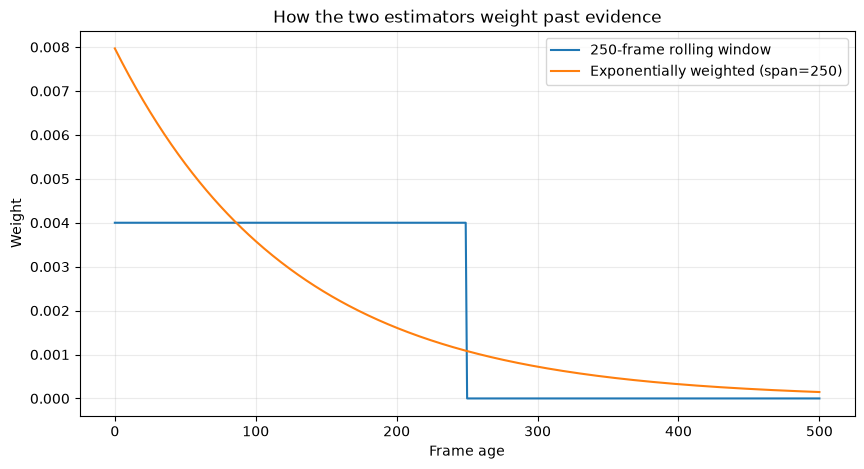

In [6]:
alpha = 2 / (ewm_span + 1)
max_age = 500

ages = np.arange(max_age + 1)

# A rolling window gives identical weight to every frame up to age 249,
# then removes the frame completely once it reaches age 250.
rolling_weights = np.where(
    ages < window_size,
    1 / window_size,
    0.0,
)

# With a long history, exponentially weighted observations decline
# geometrically with age rather than reaching a hard cutoff.
ewm_weights = alpha * (1 - alpha) ** ages

# Plot the weight assigned to a past result according to how old it is.
plt.figure(figsize=(10, 5))
plt.plot(ages, rolling_weights, label="250-frame rolling window")
plt.plot(ages, ewm_weights, label="Exponentially weighted (span=250)")

plt.xlabel("Frame age")
plt.ylabel("Weight")
plt.title("How the two estimators weight past evidence")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### What the weighting curves show

The difference is not just that one estimator has a cutoff and the other does not.

The exponentially weighted estimate **redistributes** attention across the player's history.

Compared with the 250-frame rolling window:

- very recent frames receive more weight;
- older frames inside the rolling window receive progressively less;
- frames beyond 250 do not suddenly disappear, but retain a small and declining influence.

The rolling estimator therefore has a flat memory followed by a cliff.

The exponentially weighted estimator has a sloping memory with a long tail.

Because the two estimators have comparable effective sample sizes, this gives us a useful controlled comparison of different ways to forget old evidence.

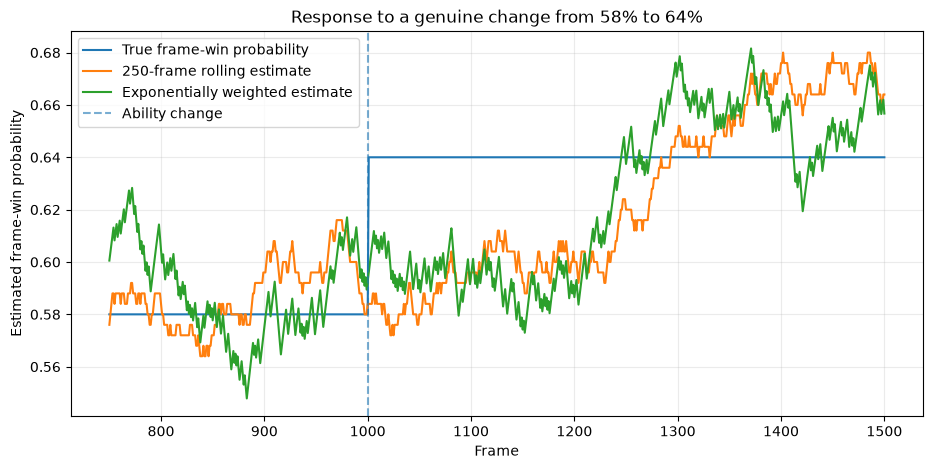

In [7]:
plot_start = 750
plot_end = 1_500

# Focus on the period around the genuine change in ability so we can
# compare how quickly each estimator moves away from stale history.
plot_data = career[
    career["frame"].between(plot_start, plot_end)
]

plt.figure(figsize=(11, 5))

plt.plot(
    plot_data["frame"],
    plot_data["true_p"],
    label="True frame-win probability",
)

plt.plot(
    plot_data["frame"],
    plot_data["rolling_250"],
    label="250-frame rolling estimate",
)

plt.plot(
    plot_data["frame"],
    plot_data["ewm_250"],
    label="Exponentially weighted estimate",
)

# Mark the point where the underlying ability genuinely changes.
plt.axvline(
    n_pre_change,
    linestyle="--",
    alpha=0.6,
    label="Ability change",
)

plt.xlabel("Frame")
plt.ylabel("Estimated frame-win probability")
plt.title("Response to a genuine change from 58% to 64%")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### One career mixes response with random noise

The single simulated career gives us an intuitive picture, but it is not enough to establish how the estimators typically respond.

Both lines are affected by the particular sequence of wins and losses generated in this career. An apparent lead, lag or overshoot may therefore be partly random.

What we want to distinguish is:

- **responsiveness** — how the estimator behaves on average after the genuine change;
- **noise** — how much individual simulated careers wander around that average.

We will therefore repeat the same 58% → 64% career many times and examine the average path of each estimator.

This keeps the sporting model unchanged while allowing the different memory rules to reveal their systematic behaviour.

In [8]:
n_careers = 10_000

# Store the average estimate at each frame across all repeated careers.
mean_rolling_250 = np.full(len(true_p), np.nan)
mean_ewm_250 = np.empty(len(true_p))

# Maintain only the information needed to update each estimator.
# This avoids storing every result from all 10,000 simulated careers.
rolling_buffer = np.zeros((window_size, n_careers), dtype=np.int8)
rolling_sum = np.zeros(n_careers, dtype=np.int16)

ewm_numerator = np.zeros(n_careers)
ewm_weight_sum = 0.0

# Use a separate fixed seed so the repeated-career experiment is
# reproducible without depending on the earlier single-career simulation.
repeat_rng = np.random.default_rng(12345)

for i, p in enumerate(true_p):
    # Generate this frame's result independently for every simulated career.
    wins = (repeat_rng.random(n_careers) < p).astype(np.int8)

    # Update the 250-frame rolling window by removing the result that
    # occupied this position previously and inserting the new result.
    buffer_position = i % window_size
    rolling_sum -= rolling_buffer[buffer_position]
    rolling_buffer[buffer_position] = wins
    rolling_sum += wins

    # A complete rolling estimate exists only after 250 observations.
    if i >= window_size - 1:
        mean_rolling_250[i] = (rolling_sum / window_size).mean()

    # Update the normalized exponentially weighted average.
    # Older contributions are reduced by (1 - alpha) each frame.
    ewm_numerator = wins + (1 - alpha) * ewm_numerator
    ewm_weight_sum = 1 + (1 - alpha) * ewm_weight_sum

    mean_ewm_250[i] = (ewm_numerator / ewm_weight_sum).mean()

In [9]:
# Choose checkpoints that show the initial response and what happens
# once the rolling window has completely discarded the old 58% regime.
check_frames = [1_000, 1_050, 1_100, 1_250, 1_500]

response_check = pd.DataFrame({
    "frame": check_frames,
    "true_p": [true_p[frame - 1] for frame in check_frames],
    "rolling_250": [mean_rolling_250[frame - 1] for frame in check_frames],
    "ewm_250": [mean_ewm_250[frame - 1] for frame in check_frames],
})

# Display percentages to make the size of the response easier to compare.
(response_check.set_index("frame") * 100).round(2)

,true_p,rolling_250,ewm_250
frame,,,
1000,58.0,57.99,57.99
1050,64.0,59.18,59.98
1100,64.0,60.35,61.26
1250,64.0,64.00,63.19
1500,64.0,63.97,63.85


### Gradual forgetting changes the shape of the response

Averaging across 10,000 simulated careers reveals a systematic difference that was difficult to separate from noise in a single career.

Immediately after the change, the exponentially weighted estimate responds more quickly.

After 50 post-change frames, its average estimate is about 60.0%, compared with about 59.2% for the rolling window. After 100 post-change frames, the corresponding averages are about 61.3% and 60.4%.

This happens because exponential weighting gives more influence to the newest observations than the equally weighted rolling window does.

But the relationship later reverses.

After 250 post-change frames, the rolling window has discarded every observation from the old 58% regime. Its expected history is now entirely representative of the player's current 64% ability.

The exponentially weighted estimator behaves differently. Old observations never encounter a hard boundary at which their weight becomes exactly zero. Their influence continues to decay, so some residual effect from the old regime remains.

The result is therefore not simply that gradual forgetting is "faster" or "slower".

It produces a different response shape:

- **more responsive initially**, because recent evidence receives extra weight;
- **more gradual later**, because stale evidence fades rather than disappearing completely at a fixed age.

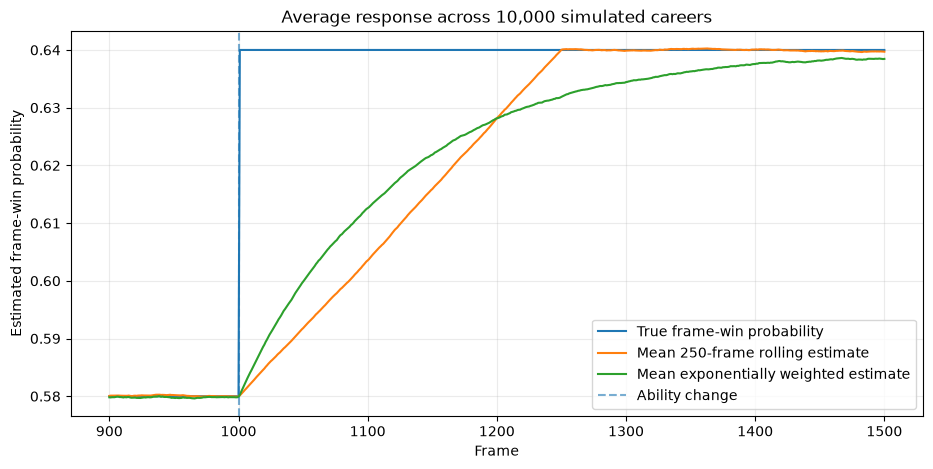

In [10]:
mean_response = pd.DataFrame({
    "frame": np.arange(1, len(true_p) + 1),
    "true_p": true_p,
    "rolling_250": mean_rolling_250,
    "ewm_250": mean_ewm_250,
})

# Focus on the change region so the systematic response shape is easy to see.
mean_plot = mean_response[
    mean_response["frame"].between(900, 1_500)
]

plt.figure(figsize=(11, 5))

plt.plot(
    mean_plot["frame"],
    mean_plot["true_p"],
    label="True frame-win probability",
)

plt.plot(
    mean_plot["frame"],
    mean_plot["rolling_250"],
    label="Mean 250-frame rolling estimate",
)

plt.plot(
    mean_plot["frame"],
    mean_plot["ewm_250"],
    label="Mean exponentially weighted estimate",
)

# Mark the boundary between the 58% and 64% regimes.
plt.axvline(
    n_pre_change,
    linestyle="--",
    alpha=0.6,
    label="Ability change",
)

plt.xlabel("Frame")
plt.ylabel("Estimated frame-win probability")
plt.title("Average response across 10,000 simulated careers")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### The average paths reveal two different kinds of forgetting

With random career-to-career variation largely averaged away, the contrast becomes much clearer.

The 250-frame rolling estimate responds almost linearly after the change. Each new 64% frame enters with the same weight while one 58% frame eventually leaves with the same weight. After 250 post-change frames, none of the old regime remains in the window.

The exponentially weighted estimate behaves differently.

It moves more sharply at first because recent evidence receives greater weight. Its response then slows as it approaches the new 64% level, because increasingly small amounts of older evidence remain influential.

The two response paths therefore cross.

Gradual forgetting is initially more responsive, but it does not have an equivalent of the rolling window's frame-250 moment when all stale evidence disappears at once.

This is the practical consequence of replacing a hard memory boundary with continuous decay.

In [11]:
stable_p = 0.64
n_stable_frames = 2_000
n_stable_careers = 10_000

# Keep the final rolling and exponentially weighted estimate for each
# simulated career so we can compare their distributions directly.
stable_rolling_buffer = np.zeros(
    (window_size, n_stable_careers),
    dtype=np.int8,
)
stable_rolling_sum = np.zeros(n_stable_careers, dtype=np.int16)

stable_ewm_numerator = np.zeros(n_stable_careers)
stable_ewm_weight_sum = 0.0

# Use another independent fixed seed for this sanity-check experiment.
stable_rng = np.random.default_rng(54321)

for i in range(n_stable_frames):
    # Every frame in this experiment is generated from the same true 64% ability.
    wins = (
        stable_rng.random(n_stable_careers) < stable_p
    ).astype(np.int8)

    # Update the 250-frame rolling estimator.
    buffer_position = i % window_size
    stable_rolling_sum -= stable_rolling_buffer[buffer_position]
    stable_rolling_buffer[buffer_position] = wins
    stable_rolling_sum += wins

    # Update the normalized exponentially weighted estimator.
    stable_ewm_numerator = (
        wins + (1 - alpha) * stable_ewm_numerator
    )
    stable_ewm_weight_sum = (
        1 + (1 - alpha) * stable_ewm_weight_sum
    )

# Extract the final estimate from each of the 10,000 stable careers.
stable_rolling_final = stable_rolling_sum / window_size
stable_ewm_final = stable_ewm_numerator / stable_ewm_weight_sum

stable_check = pd.DataFrame({
    "estimator": [
        "250-frame rolling",
        "Exponentially weighted",
    ],
    "mean": [
        stable_rolling_final.mean(),
        stable_ewm_final.mean(),
    ],
    "sd_percentage_points": [
        stable_rolling_final.std(ddof=1) * 100,
        stable_ewm_final.std(ddof=1) * 100,
    ],
})

stable_check.round({
    "mean": 4,
    "sd_percentage_points": 2,
})

,estimator,mean,sd_percentage_points
0,250-frame rolling,0.6403,3.08
1,Exponentially weighted,0.6402,3.07


### Matching effective sample size gives comparable stability

The stable-ability sanity check confirms that the comparison is behaving as intended.

With true ability fixed at 64% throughout 10,000 simulated careers:

- the 250-frame rolling estimator averaged 64.03%, with a standard deviation of 3.08 percentage points;
- the exponentially weighted estimator averaged 64.02%, with a standard deviation of 3.07 percentage points.

Both estimators are therefore centred on the correct ability level and have almost identical long-run variability.

This matters because it isolates the feature we intended to change.

The different response to the earlier 58% → 64% shift is not simply the result of comparing a stable estimator with a noisier one. With roughly the same effective amount of information, the estimators behave differently because they distribute that information across the past differently.

The comparison is therefore principally about **memory shape**:

- equal weight followed by a hard cutoff;
- greater weight on recent evidence followed by gradual decay.

In [12]:
# Apply both estimators directly to the true probability path.
# Because weighted averages are linear, this gives their expected
# response without any random frame-to-frame variation.
expected_rolling = (
    pd.Series(true_p)
    .rolling(window=window_size, min_periods=window_size)
    .mean()
)

expected_ewm = (
    pd.Series(true_p)
    .ewm(span=ewm_span, adjust=True)
    .mean()
)

# Check how far each estimator still sits below the new 64% ability
# after 250 and 500 post-change frames.
stale_check_frames = [1_250, 1_500]

stale_check = pd.DataFrame({
    "frame": stale_check_frames,
    "rolling_expected": [
        expected_rolling.iloc[frame - 1]
        for frame in stale_check_frames
    ],
    "ewm_expected": [
        expected_ewm.iloc[frame - 1]
        for frame in stale_check_frames
    ],
})

stale_check["rolling_shortfall_pp"] = (
    p_after - stale_check["rolling_expected"]
) * 100

stale_check["ewm_shortfall_pp"] = (
    p_after - stale_check["ewm_expected"]
) * 100

stale_check.round({
    "rolling_expected": 4,
    "ewm_expected": 4,
    "rolling_shortfall_pp": 2,
    "ewm_shortfall_pp": 2,
})

,frame,rolling_expected,ewm_expected,rolling_shortfall_pp,ewm_shortfall_pp
0,1250,0.64,0.6319,0.0,0.81
1,1500,0.64,0.6389,0.0,0.11


### Old evidence fades rather than vanishes

The exact expected paths put a number on the exponential estimator's long tail.

After 250 post-change frames:

- the rolling estimator is exactly centred on the new 64% ability;
- the exponentially weighted estimator is still centred at about 63.19%, a shortfall of 0.81 percentage points.

After 500 post-change frames:

- the rolling estimator remains centred on 64%;
- the exponential estimator has reached about 63.89%, leaving only a 0.11 percentage-point shortfall.

This is the defining consequence of gradual forgetting.

The exponentially weighted estimator has no single frame at which the old 58% regime disappears completely. Its influence becomes progressively smaller instead.

The cost of avoiding a hard cutoff is therefore a fading residual memory of older conditions.

But that same weighting rule was also what allowed the estimator to respond more strongly to the newest evidence immediately after the change.

## 5. Conclusion

A fixed rolling window is not the only way to forget old evidence.

In the same deliberately simple 58% → 64% ability model, replacing the 250-frame hard cutoff with an exponentially weighted estimate changed **how the estimator responded to change**, even though the two methods had almost identical long-run variability under stable ability.

The 250-frame rolling estimator:

- gives equal weight to every retained observation;
- reacts steadily as new evidence replaces old evidence;
- completely forgets the old regime after 250 post-change frames.

The exponentially weighted estimator:

- gives greater weight to the newest evidence;
- reacts more strongly immediately after the change;
- gradually reduces the influence of older results rather than removing them at a fixed boundary;
- retains a small residual memory of the old regime even after 250 frames.

Neither behaviour is automatically better.

The rolling window gives us a clear boundary between remembered and forgotten history, but that boundary is arbitrary and discontinuous.

Exponential weighting avoids that cliff, but old evidence never disappears at one exact moment.

The central result is:

> **Old evidence does not have to disappear all at once. How we let it fade changes the shape of an estimator's response to genuine change.**

This study deliberately used only one exponential decay setting. It does not establish an optimal weighting rule or determine which estimator should be preferred in practice.

A natural next question is whether these conclusions still look the same when underlying ability itself changes gradually rather than jumping abruptly from one level to another.

## 6. Scope and limitations

This study isolates one modelling choice only: **how historical frame results are weighted when estimating current ability**.

The underlying sporting model remains intentionally simple.

We still assume:

- independent frames;
- no momentum or within-match dependence;
- no parameter uncertainty;
- a known abrupt change from 58% to 64%;
- the same change point in every simulated career;
- no opponent effects, match format effects or contextual variables.

The exponentially weighted estimator also uses one deliberately chosen decay setting: `span=250`.

That choice was made to give the estimator approximately the same long-run effective sample size as the 250-frame rolling window, so the comparison focuses on memory shape rather than simply comparing different levels of statistical noise.

We have not tested whether `span=250` is optimal.

Nor have we shown that exponential weighting is preferable to a rolling window in real sporting data.

The narrower conclusion is simply that two estimators with similar long-run stability can respond differently to genuine change because they remember the past differently.